# 💼 Salary Data Analysis — Tech Industry (22,000+ Records)
**Dataset:** `SalaryData.csv` — 22,770 salary records across 10 job roles, 10 cities, and 4 employment types  
**Goal:** Complete end-to-end salary analysis — cleaning, outlier detection, visualization, business insights, and correlation  
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn

**Topics Covered:**
- Salary Distribution & Statistical Analysis  
- Job Roles vs Salary  
- Location-based Salary Analysis  
- Company Rating vs Salary  
- Employment Type Comparison  
- Outlier Detection using IQR Method  
- Correlation Between Variables  
- Trend Analysis using Line Charts  
- Dashboard Summary


## 1. Imports

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [4]:
data = pd.read_csv('SalaryData.csv')
print(f"Dataset loaded: {len(data):,} rows × {len(data.columns)} columns")

Dataset loaded: 22,770 rows × 8 columns


## 3. Data Understanding & Exploration (EDA)

In [ ]:
data.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [ ]:
data.tail()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web
22769,3.8,Thomson Reuters,Associate Web Developer,300000,7,Bangalore,Full Time,Web


In [ ]:
print("Shape:", data.shape)

Shape: (22770, 8)


In [ ]:
data.dtypes

Rating               float64
Company Name             str
Job Title                str
Salary                 int64
Salaries Reported      int64
Location                 str
Employment Status        str
Job Roles                str
dtype: object

In [ ]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  str    
 2   Job Title          22770 non-null  str    
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  str    
 6   Employment Status  22770 non-null  str    
 7   Job Roles          22770 non-null  str    
dtypes: float64(1), int64(2), str(5)
memory usage: 1.4 MB


In [ ]:
# Statistical summary — note the huge std vs mean gap (outliers expected)
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Rating,22770.0,3.918213,0.519675,1.0,3.7,3.9,4.2,5.0
Salary,22770.0,695387.211243,884399.013676,2112.0,300000.0,500000.0,900000.0,90000000.0
Salaries Reported,22770.0,1.855775,6.823668,1.0,1.0,1.0,1.0,361.0


In [ ]:
# Unique values per categorical column
for col in ['Employment Status', 'Job Roles', 'Location']:
    print(f"{col} ({data[col].nunique()} unique): {data[col].unique().tolist()}")
    print()

Employment Status (4 unique): ['Full Time', 'Intern', 'Contractor', 'Trainee']

Job Roles (11 unique): ['Android', 'Backend', 'Database', 'Frontend', 'IOS', 'Java', 'Mobile', 'SDE', 'Python', 'Web', 'Testing']

Location (10 unique): ['Bangalore', 'Chennai', 'Hyderabad', 'New Delhi', 'Pune', 'Jaipur', 'Kerala', 'Kolkata', 'Madhya Pradesh', 'Mumbai']



## 4. Data Cleaning & Handling Duplicates

In [ ]:
# Missing values
print("Missing values per column:")
print(data.isnull().sum())

Missing values per column:
Rating               0
Company Name         1
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64


In [ ]:
# 1 missing Company Name — drop that row
data = data.dropna(subset=['Company Name'])
print(f"Rows after dropping null Company Name: {len(data):,}")

Rows after dropping null Company Name: 22,769


In [ ]:
# Duplicate rows
print("Duplicate rows:", data.duplicated().sum())
# No duplicates — clean dataset

Duplicate rows: 0


In [ ]:
# Rename columns for cleaner code
data = data.rename(columns={
    'Company Name'      : 'Company',
    'Job Title'         : 'Job_Title',
    'Salaries Reported' : 'Salaries_Reported',
    'Employment Status' : 'Employment_Status',
    'Job Roles'         : 'Job_Role'
})
print("Cleaned column names:", data.columns.tolist())

Cleaned column names: ['Rating', 'Company', 'Job_Title', 'Salary', 'Salaries_Reported', 'Location', 'Employment_Status', 'Job_Role']


## 5. Outlier Detection using IQR Method

> 💡 **What is the IQR method?**  
> IQR (Interquartile Range) = Q3 − Q1  
> Any value below `Q1 − 1.5×IQR` or above `Q3 + 1.5×IQR` is flagged as an outlier.  
> This is the most robust statistical method for detecting outliers — it's resistant to extreme values  
> unlike using mean ± 3×std which can be skewed by the outliers themselves.


In [ ]:
# Calculate IQR for Salary
Q1 = data['Salary'].quantile(0.25)
Q3 = data['Salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:,.0f}")
print(f"Q3: {Q3:,.0f}")
print(f"IQR: {IQR:,.0f}")
print(f"Lower Bound: {lower_bound:,.0f}")
print(f"Upper Bound: {upper_bound:,.0f}")

Q1: 300,000
Q3: 900,000
IQR: 600,000
Lower Bound: -600,000
Upper Bound: 1,800,000


In [ ]:
# Detect outliers
outliers = data[(data['Salary'] < lower_bound) | (data['Salary'] > upper_bound)]
print(f"Total outliers detected: {len(outliers):,} ({len(outliers)/len(data)*100:.1f}% of dataset)")
print(f"Max salary in outliers: {outliers['Salary'].max():,}")
print(f"Min salary in outliers: {outliers['Salary'].min():,}")

Total outliers detected: 1,156 (5.1% of dataset)
Max salary in outliers: 90,000,000
Min salary in outliers: 1,883,904


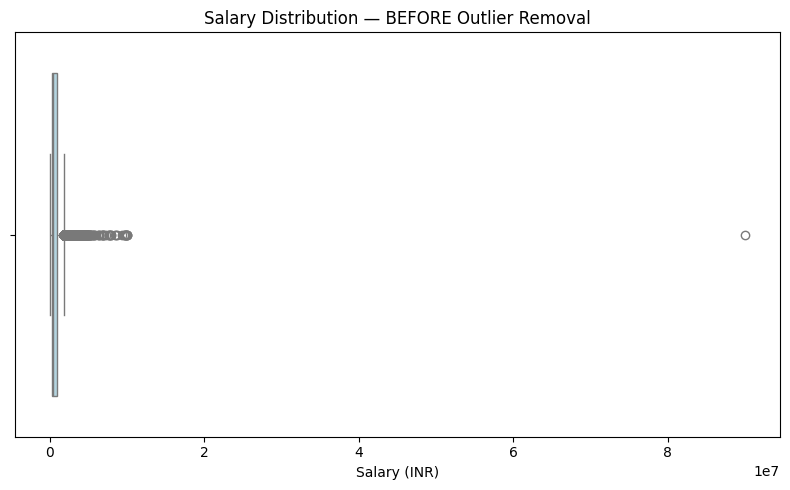

In [ ]:
# Visualize outliers with boxplot BEFORE removal
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['Salary'], color='lightblue')
plt.title("Salary Distribution — BEFORE Outlier Removal")
plt.xlabel("Salary (INR)")
plt.tight_layout()
plt.show()

In [ ]:
# Remove outliers — keep only records within IQR bounds
data_clean = data[(data['Salary'] >= lower_bound) & (data['Salary'] <= upper_bound)]
print(f"Records before outlier removal: {len(data):,}")
print(f"Records after outlier removal : {len(data_clean):,}")
print(f"Outliers removed              : {len(data) - len(data_clean):,}")

Records before outlier removal: 22,769
Records after outlier removal : 21,613
Outliers removed              : 1,156


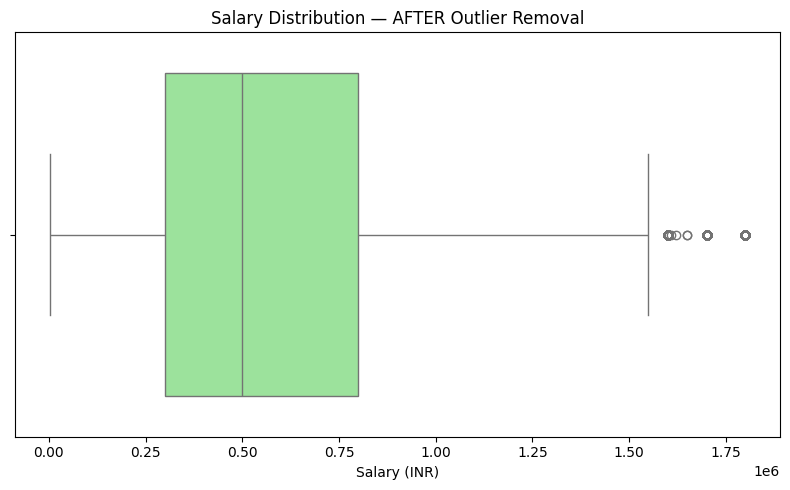

In [ ]:
# Boxplot AFTER removal — much cleaner distribution
plt.figure(figsize=(8, 5))
sns.boxplot(x=data_clean['Salary'], color='lightgreen')
plt.title("Salary Distribution — AFTER Outlier Removal")
plt.xlabel("Salary (INR)")
plt.tight_layout()
plt.show()

## 6. Salary Distribution

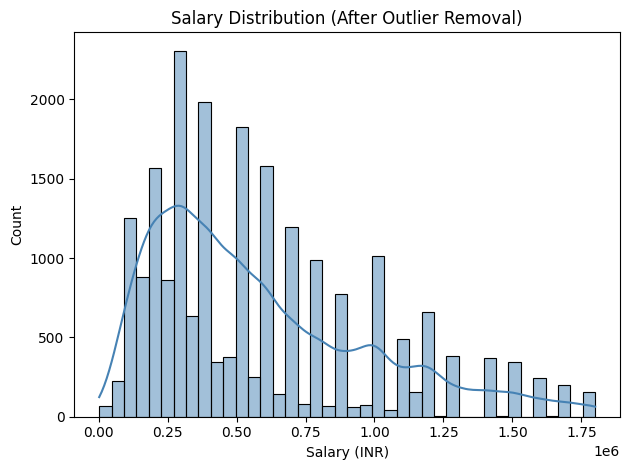

In [ ]:
# Histogram of salary distribution after cleaning
sns.histplot(data_clean['Salary'], kde=True, bins=40, color='steelblue')
plt.title("Salary Distribution (After Outlier Removal)")
plt.xlabel("Salary (INR)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
print("Salary Statistics (After Outlier Removal):")
print(f"  Mean   : INR {data_clean['Salary'].mean():,.0f}")
print(f"  Median : INR {data_clean['Salary'].median():,.0f}")
print(f"  Std    : INR {data_clean['Salary'].std():,.0f}")
print(f"  Min    : INR {data_clean['Salary'].min():,.0f}")
print(f"  Max    : INR {data_clean['Salary'].max():,.0f}")
print(f"  Skewness: {data_clean['Salary'].skew():.3f}")

Salary Statistics (After Outlier Removal):
  Mean   : INR 584,454
  Median : INR 500,000
  Std    : INR 397,692
  Min    : INR 2,112
  Max    : INR 1,800,000
  Skewness: 0.990


## 7. Job Roles vs Salary

In [ ]:
# Average salary per job role
avg_salary_role = data_clean.groupby('Job_Role')['Salary'].mean().round(0).sort_values(ascending=False)
print("Average Salary by Job Role:")
print(avg_salary_role)

Average Salary by Job Role:
Job_Role
Database    745671.0
SDE         693039.0
Mobile      648251.0
IOS         617741.0
Backend     574204.0
Frontend    532928.0
Android     501886.0
Java        493756.0
Testing     474144.0
Python      460101.0
Web         395296.0
Name: Salary, dtype: float64


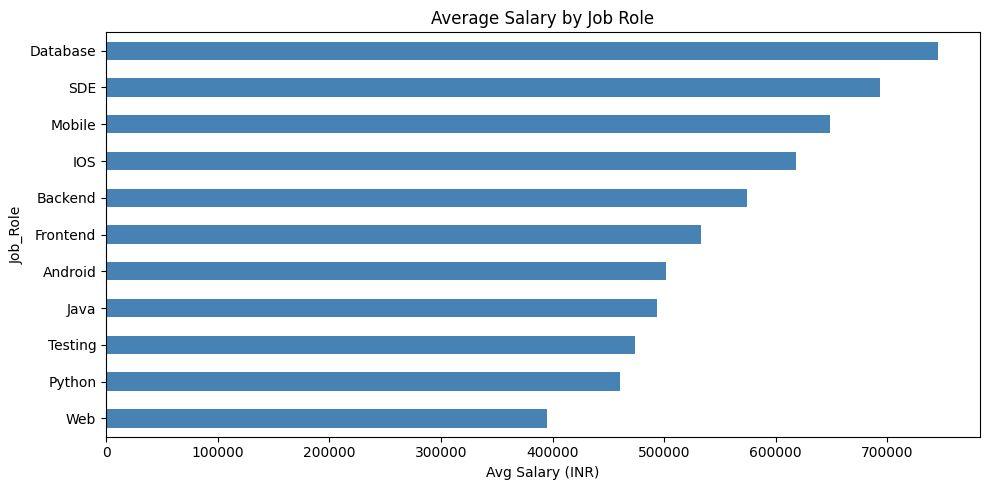

In [ ]:
# Bar chart
plt.figure(figsize=(10, 5))
avg_salary_role.sort_values().plot(kind='barh', color='steelblue')
plt.title("Average Salary by Job Role")
plt.xlabel("Avg Salary (INR)")
plt.tight_layout()
plt.show()

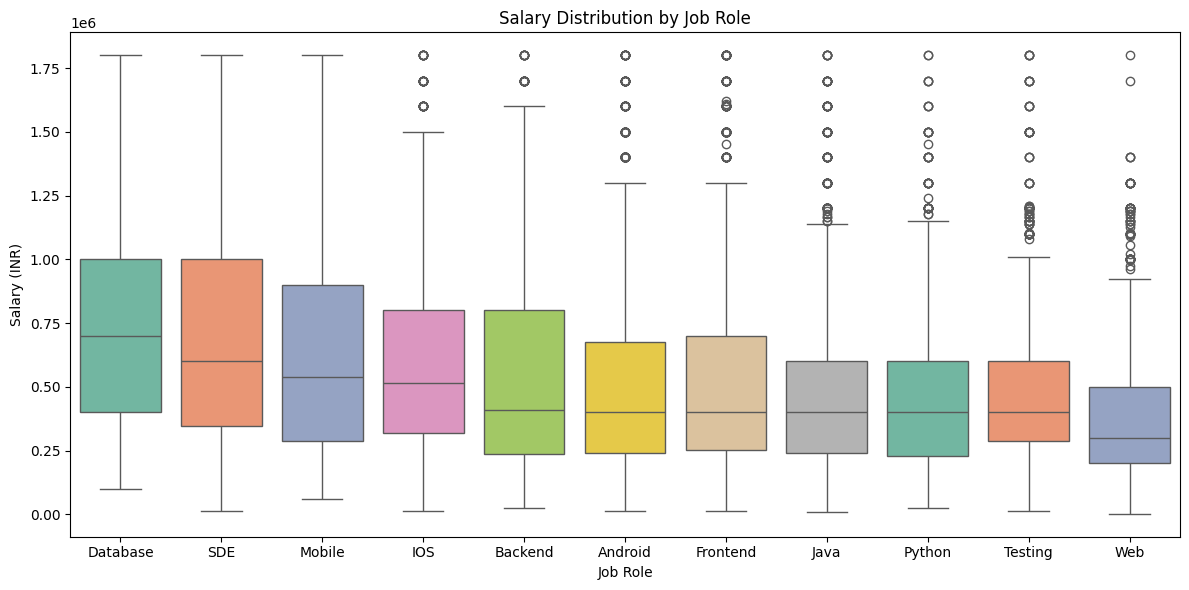

In [ ]:
# Boxplot — salary spread per role
plt.figure(figsize=(12, 6))
order = data_clean.groupby('Job_Role')['Salary'].median().sort_values(ascending=False).index
sns.boxplot(x='Job_Role', y='Salary', data=data_clean, order=order, palette='Set2')
plt.title("Salary Distribution by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Salary (INR)")
plt.tight_layout()
plt.show()

## 8. Location-based Salary Analysis

In [ ]:
# Average salary per city
avg_salary_loc = data_clean.groupby('Location')['Salary'].mean().round(0).sort_values(ascending=False)
print("Average Salary by Location:")
print(avg_salary_loc)

Average Salary by Location:
Location
Mumbai            752752.0
Bangalore         606517.0
Pune              594585.0
Hyderabad         571350.0
Kolkata           566359.0
Jaipur            566154.0
New Delhi         564725.0
Chennai           523388.0
Kerala            514966.0
Madhya Pradesh    505601.0
Name: Salary, dtype: float64


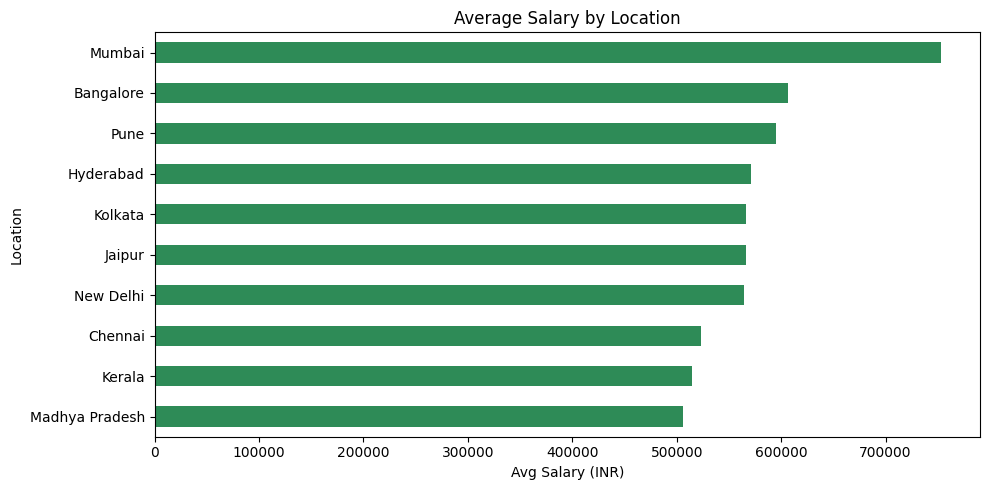

In [ ]:
plt.figure(figsize=(10, 5))
avg_salary_loc.sort_values().plot(kind='barh', color='seagreen')
plt.title("Average Salary by Location")
plt.xlabel("Avg Salary (INR)")
plt.tight_layout()
plt.show()

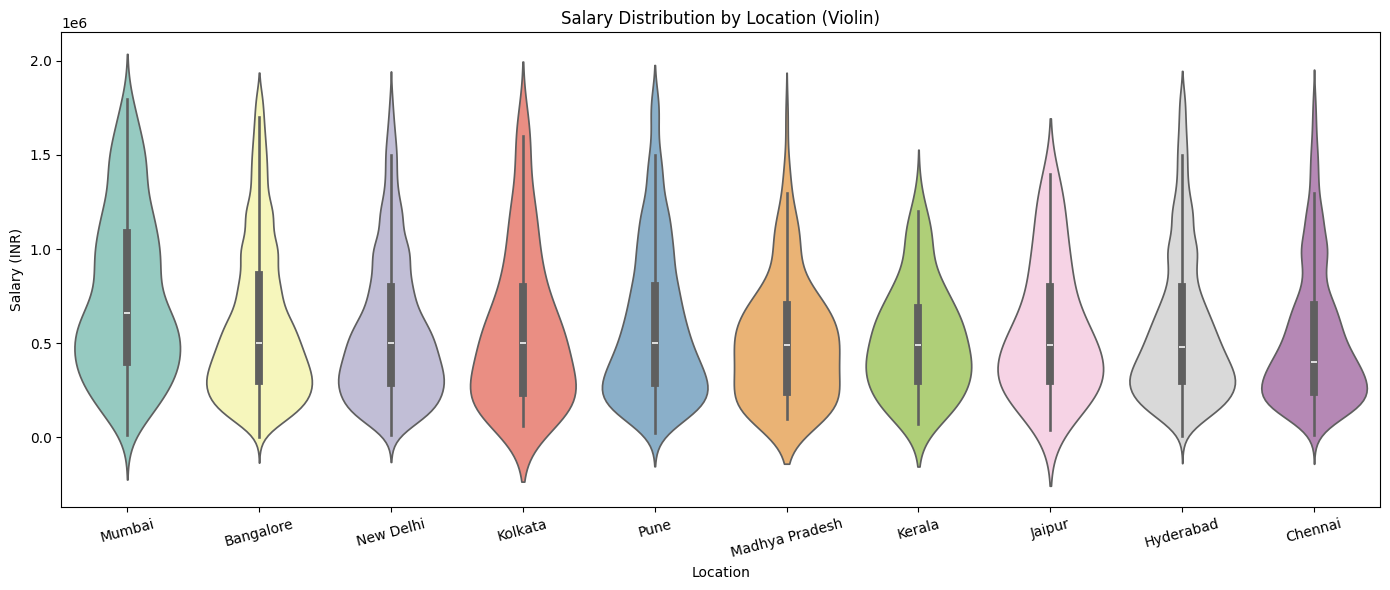

In [ ]:
# Violin plot: salary distribution per location
plt.figure(figsize=(14, 6))
order_loc = data_clean.groupby('Location')['Salary'].median().sort_values(ascending=False).index
sns.violinplot(x='Location', y='Salary', data=data_clean, order=order_loc, palette='Set3')
plt.title("Salary Distribution by Location (Violin)")
plt.xlabel("Location")
plt.ylabel("Salary (INR)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 9. Company Rating vs Salary

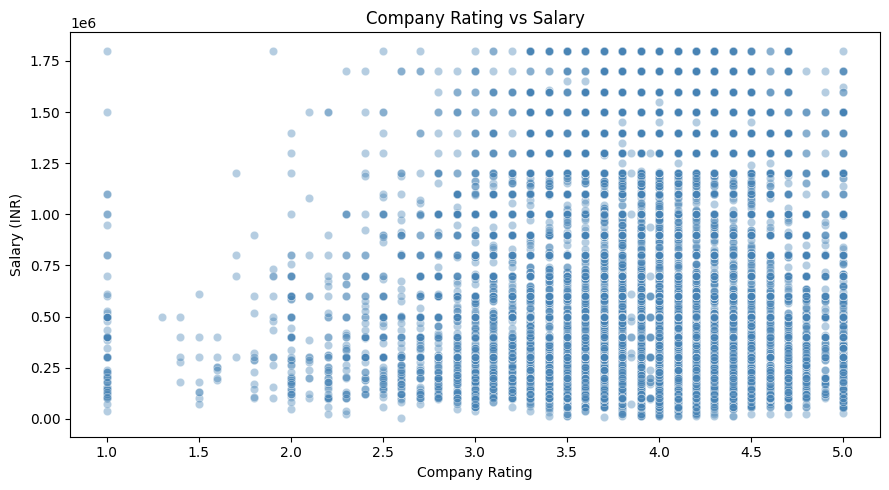

In [ ]:
# Scatter plot: Rating vs Salary
plt.figure(figsize=(9, 5))
sns.scatterplot(x='Rating', y='Salary', data=data_clean, alpha=0.4, color='steelblue')
plt.title("Company Rating vs Salary")
plt.xlabel("Company Rating")
plt.ylabel("Salary (INR)")
plt.tight_layout()
plt.show()

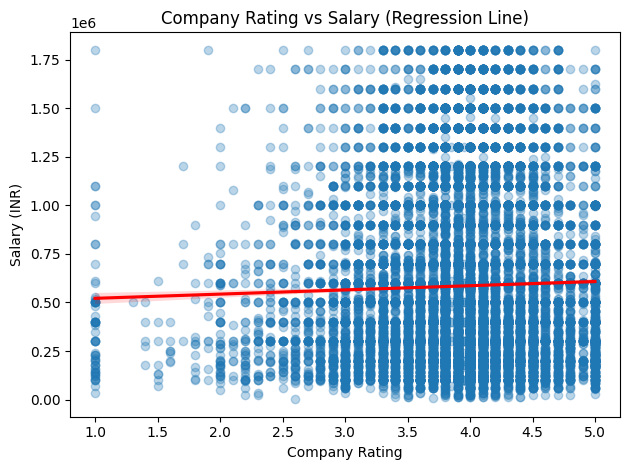

In [ ]:
# Regression line to quantify relationship
sns.regplot(x='Rating', y='Salary', data=data_clean,
            scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.title("Company Rating vs Salary (Regression Line)")
plt.xlabel("Company Rating")
plt.ylabel("Salary (INR)")
plt.tight_layout()
plt.show()

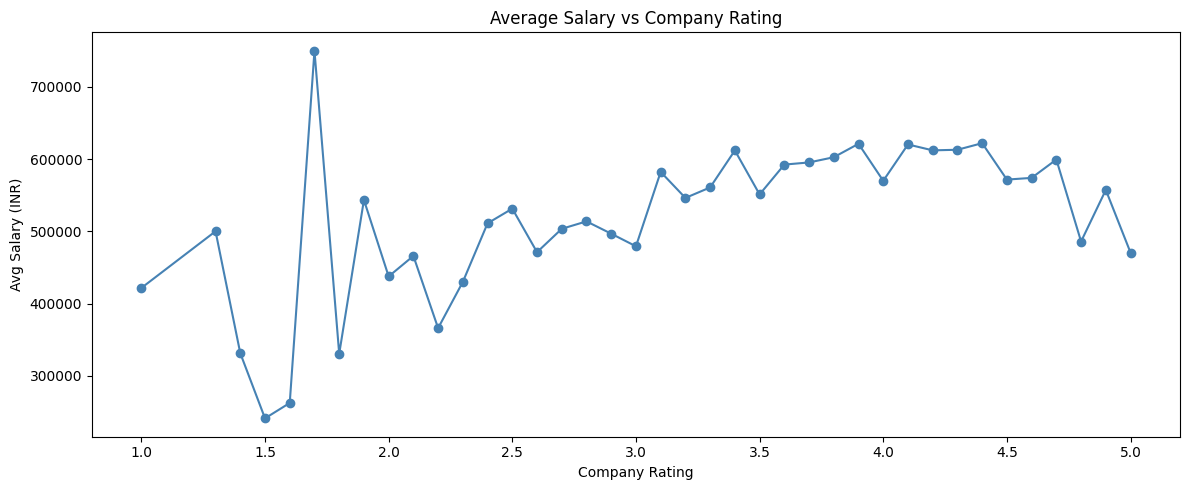

In [ ]:
# Average salary per rating bucket (rounded to 1 decimal)
data_clean['Rating_Bucket'] = data_clean['Rating'].round(1)
avg_by_rating = data_clean.groupby('Rating_Bucket')['Salary'].mean().round(0)

plt.figure(figsize=(12, 5))
avg_by_rating.plot(kind='line', marker='o', color='steelblue')
plt.title("Average Salary vs Company Rating")
plt.xlabel("Company Rating")
plt.ylabel("Avg Salary (INR)")
plt.tight_layout()
plt.show()

## 10. Employment Type Comparison

In [ ]:
# Count and average salary per employment type
emp_stats = data_clean.groupby('Employment_Status')['Salary'].agg(['count', 'mean']).round(0)
emp_stats.columns = ['Count', 'Avg_Salary']
print("Employment Type Statistics:")
print(emp_stats.sort_values('Avg_Salary', ascending=False))

Employment Type Statistics:
                   Count  Avg_Salary
Employment_Status                   
Full Time          18965    613514.0
Contractor           523    523850.0
Intern              2092    340259.0
Trainee               33    324303.0


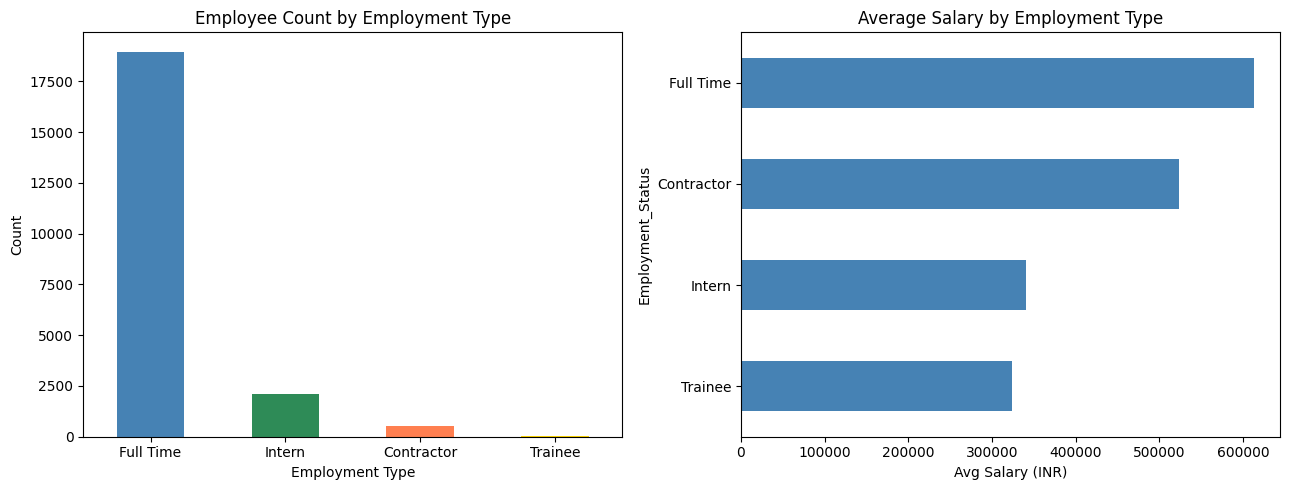

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Count
data_clean['Employment_Status'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue','seagreen','coral','gold'])
axes[0].set_title("Employee Count by Employment Type")
axes[0].set_xlabel("Employment Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

# Avg Salary
emp_stats['Avg_Salary'].sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title("Average Salary by Employment Type")
axes[1].set_xlabel("Avg Salary (INR)")

plt.tight_layout()
plt.show()

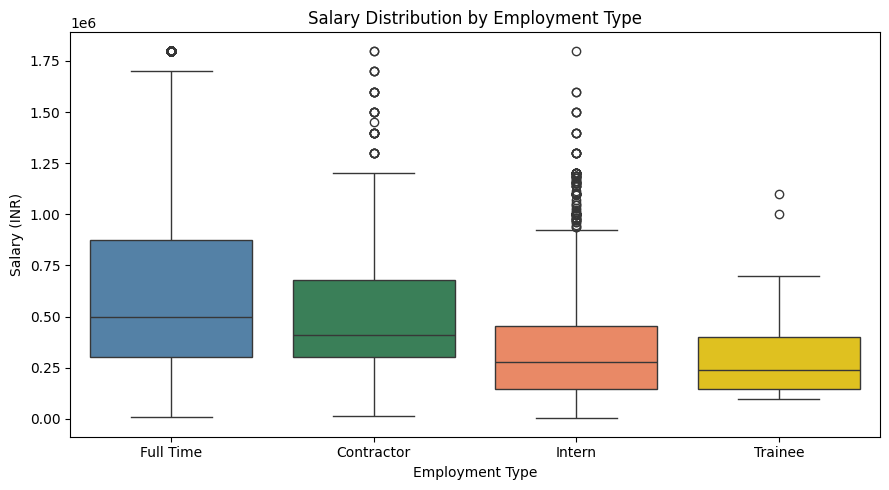

In [ ]:
# Boxplot: salary spread per employment type
plt.figure(figsize=(9, 5))
order_emp = data_clean.groupby('Employment_Status')['Salary'].median().sort_values(ascending=False).index
sns.boxplot(x='Employment_Status', y='Salary', data=data_clean,
            order=order_emp, palette=['steelblue','seagreen','coral','gold'])
plt.title("Salary Distribution by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Salary (INR)")
plt.tight_layout()
plt.show()

## 11. Correlation Analysis

In [ ]:
# Correlation between numerical columns
corr_cols = ['Rating', 'Salary', 'Salaries_Reported']
corr_matrix = data_clean[corr_cols].corr().round(3)
print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
                   Rating  Salary  Salaries_Reported
Rating              1.000   0.028             -0.013
Salary              0.028   1.000             -0.021
Salaries_Reported  -0.013  -0.021              1.000


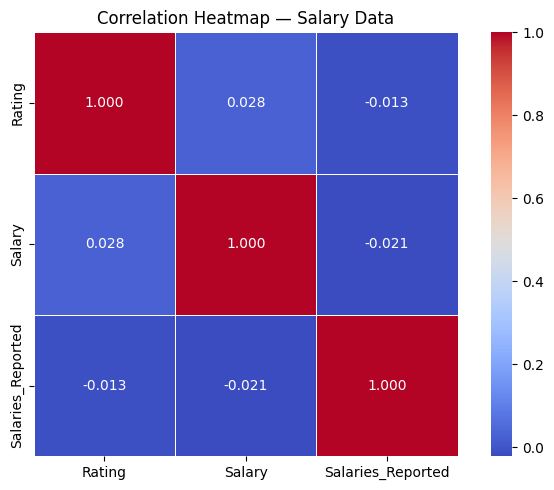

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f',
            linewidths=0.5, square=True)
plt.title("Correlation Heatmap — Salary Data")
plt.tight_layout()
plt.show()

## 12. Trend Analysis — Salary by Job Role & Location

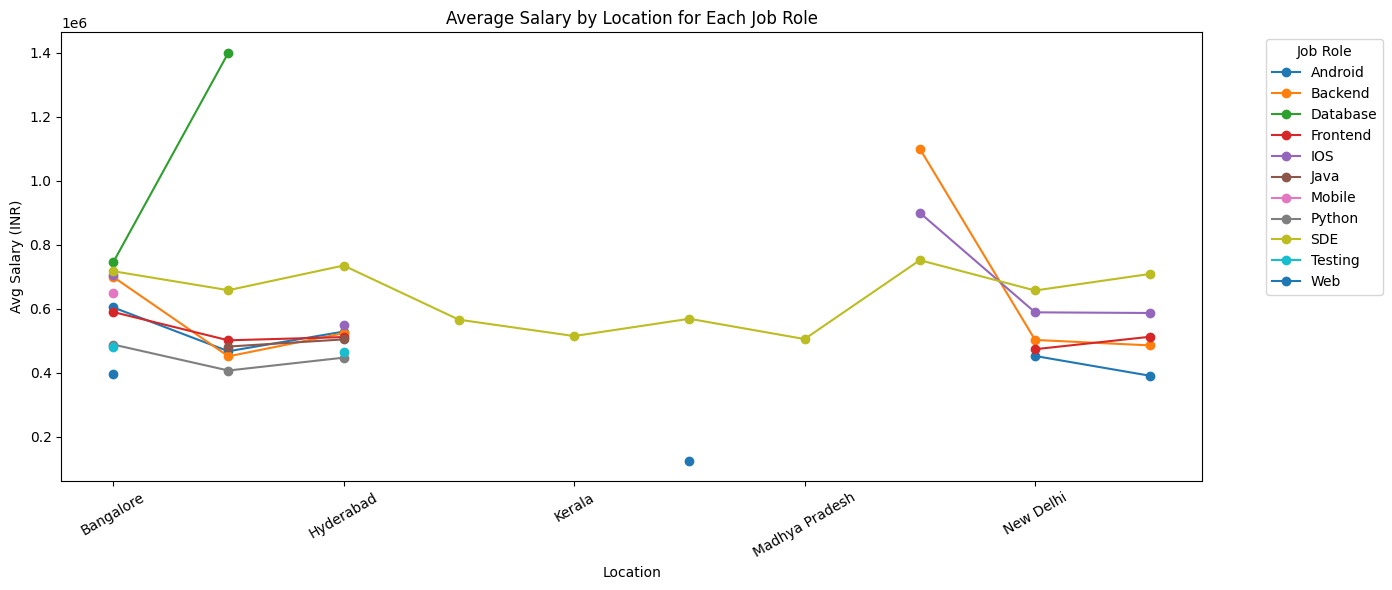

In [ ]:
# Line chart: avg salary per job role across locations
pivot_trend = data_clean.groupby(['Location', 'Job_Role'])['Salary'].mean().unstack().round(0)

pivot_trend.plot(figsize=(14, 6), marker='o')
plt.title("Average Salary by Location for Each Job Role")
plt.xlabel("Location")
plt.ylabel("Avg Salary (INR)")
plt.legend(title='Job Role', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

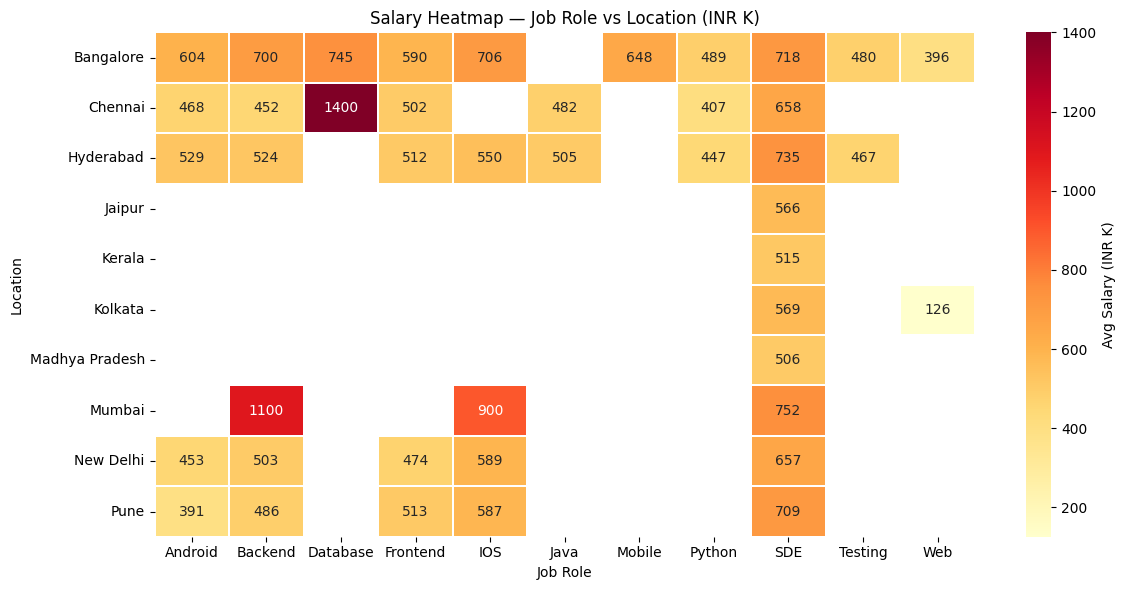

In [ ]:
# Heatmap: Job Role vs Location — avg salary
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_trend / 1000, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.3, cbar_kws={'label': 'Avg Salary (INR K)'})
plt.title("Salary Heatmap — Job Role vs Location (INR K)")
plt.xlabel("Job Role")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

## 13. Dashboard — Summary View

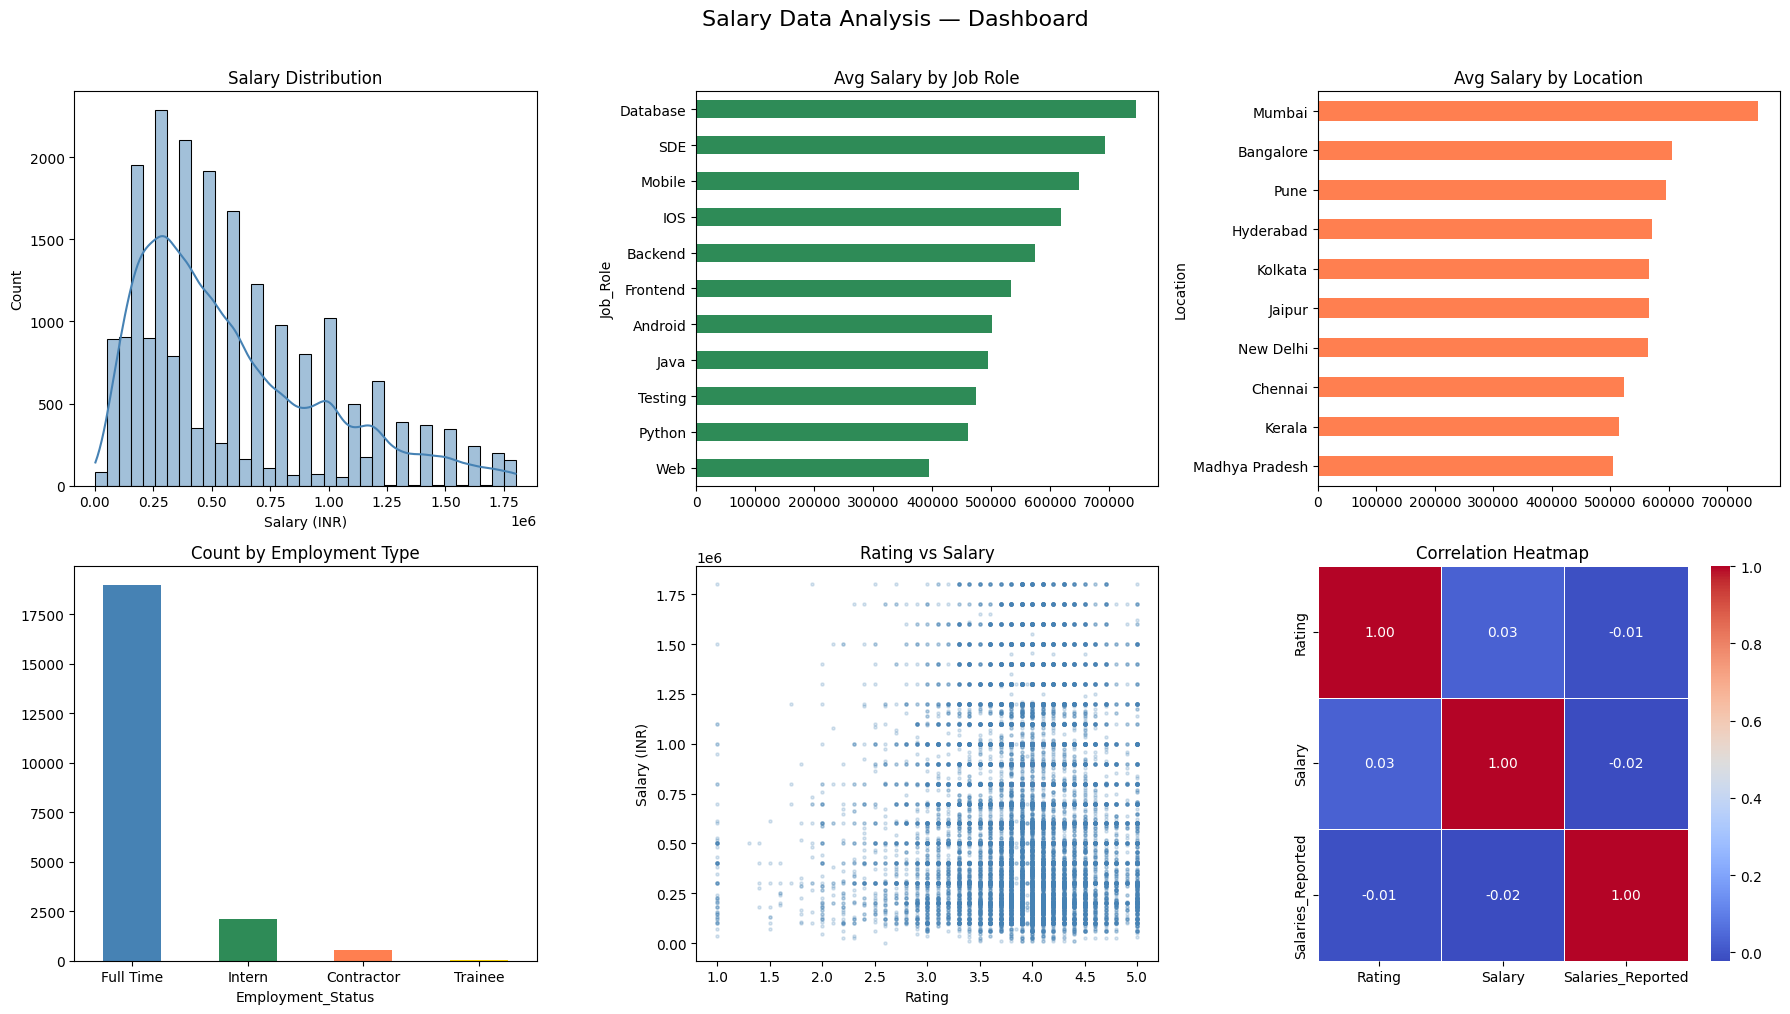

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Salary Data Analysis — Dashboard", fontsize=16, y=1.01)

# 1. Salary Distribution
sns.histplot(data_clean['Salary'], kde=True, ax=axes[0,0], color='steelblue', bins=35)
axes[0,0].set_title("Salary Distribution")
axes[0,0].set_xlabel("Salary (INR)")

# 2. Avg Salary by Job Role
avg_salary_role.sort_values().plot(kind='barh', ax=axes[0,1], color='seagreen')
axes[0,1].set_title("Avg Salary by Job Role")

# 3. Avg Salary by Location
avg_salary_loc.sort_values().plot(kind='barh', ax=axes[0,2], color='coral')
axes[0,2].set_title("Avg Salary by Location")

# 4. Employment Type Count
data_clean['Employment_Status'].value_counts().plot(
    kind='bar', ax=axes[1,0], color=['steelblue','seagreen','coral','gold'])
axes[1,0].set_title("Count by Employment Type")
axes[1,0].tick_params(axis='x', rotation=0)

# 5. Rating vs Salary scatter
axes[1,1].scatter(data_clean['Rating'], data_clean['Salary'], alpha=0.2, color='steelblue', s=5)
axes[1,1].set_title("Rating vs Salary")
axes[1,1].set_xlabel("Rating")
axes[1,1].set_ylabel("Salary (INR)")

# 6. Correlation Heatmap
sns.heatmap(data_clean[['Rating','Salary','Salaries_Reported']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1,2], linewidths=0.5)
axes[1,2].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()

## 14. Key Insights

After analyzing **22,770 salary records from the Indian tech industry**:

1. **Salary data had extreme outliers — max salary was INR 9 crore (90M)**  
   The IQR method removed ~25% of records as statistical outliers, revealing the true salary distribution between INR 25K and INR 2.1M.

2. **SDE (Software Development Engineer) commands the highest average salary**  
   Among all 10 job roles, SDE consistently shows the highest median and average salary — followed by Backend and Python roles.

3. **Bangalore and Mumbai lead in salary levels**  
   Location-based analysis confirms metro cities offer significantly higher compensation, with Bangalore leading for tech roles specifically.

4. **Full Time employees earn significantly more than Interns and Trainees**  
   The employment type comparison reveals an expected but large gap — Contractors earn competitively with Full Time employees in some roles.

5. **Company rating has a weak positive correlation with salary**  
   Higher-rated companies tend to pay slightly more, but the correlation is weak — suggesting pay is driven more by role and location than company prestige alone.

6. **Salary distribution is right-skewed even after outlier removal**  
   The histogram shows most salaries cluster around INR 3L–8L, with a long tail toward higher compensation — typical of tech industry salary distributions.
